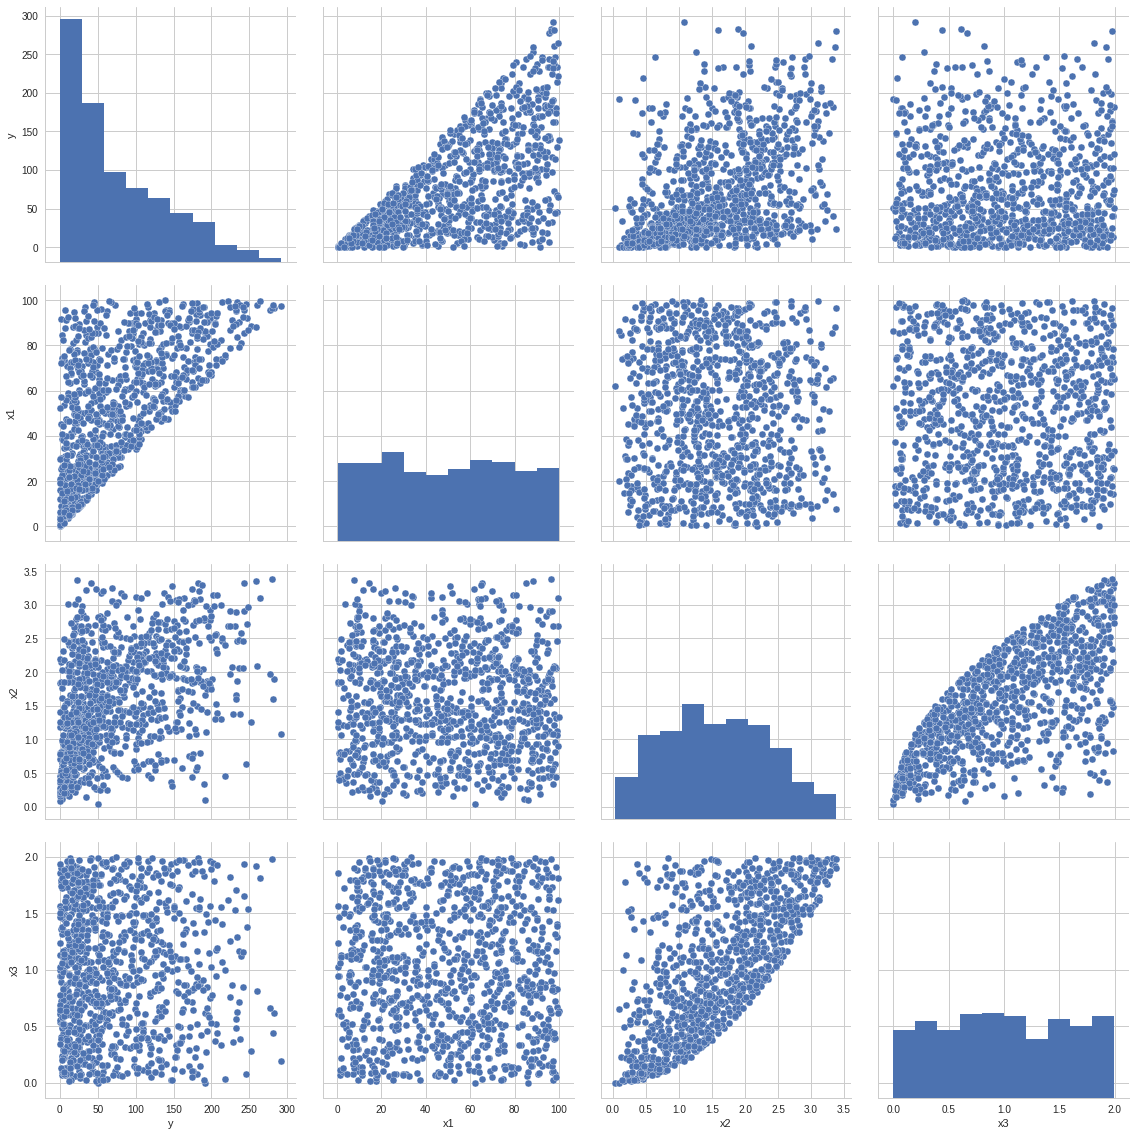

               y         x1        x2        x3
0       0.172375   1.031648  0.457893  0.627415
1       0.492644   4.168120  0.356204  0.536752
2       0.902367  91.485727  0.187076  1.774093
3      17.118149  41.857891  1.244643  1.894000
4      70.265758  43.010097  1.949242  1.162862
5      39.611799  77.313077  1.206557  1.420674
6     139.935481  95.719314  0.691728  0.163649
7      13.064866  63.211595  0.341914  0.282811
8       2.339679   2.474307  1.611975  1.373992
9      26.080398   9.134811  2.824203  1.396842
10    110.041923  70.288322  1.216231  0.472419
11     48.706407  71.479920  1.579886  1.831553
12     67.235434  32.082530  1.123204  0.300994
13     64.985170  43.876865  1.760610  1.046448
14     15.227141  41.363601  0.663902  0.598657
15     84.848256  65.449723  1.737102  1.163820
16    167.042585  78.921991  2.606082  1.604416
17     28.735741  50.162831  1.392763  1.693106
18    233.718571  99.215876  2.460650  1.285161
19     50.863726  62.240111  0.037649  0

In [85]:
# import scipy.stats as stats
# stats.f_oneway(df.ix[1:,'y'],df.ix[1:, 'x3'])
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv('ML_Data_Insight_121016.csv', header=1) 
cols = ['y','x1', 'x2', 'x3'] 
df.head()

## df.ix[0:, 'x2'] = np.sqrt(df.ix[0:, 'x2'])



sns.pairplot(df[cols], size=4) 
plt.show()

print(df)



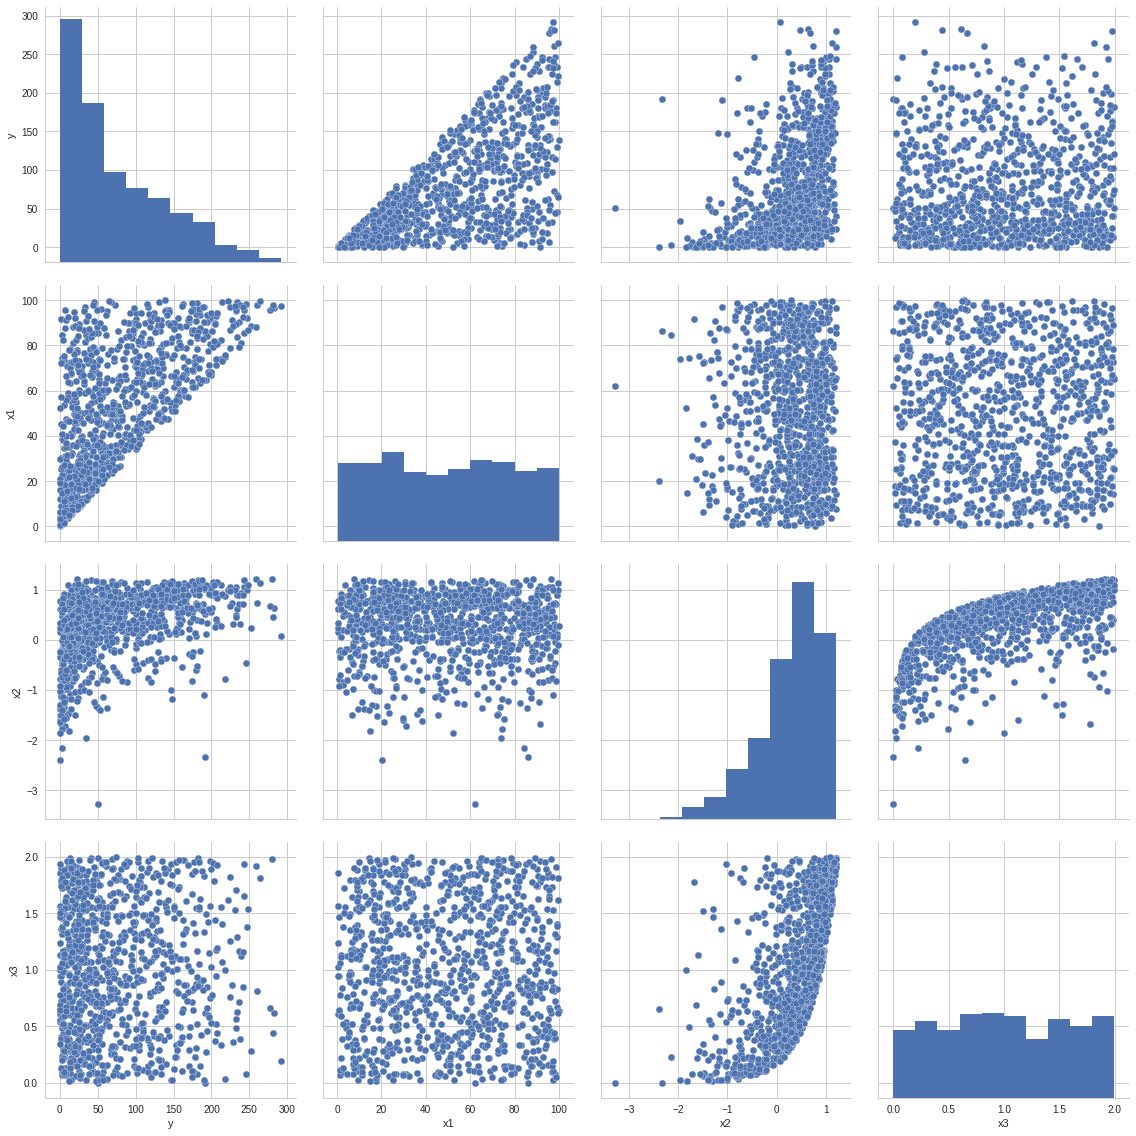

In [66]:

sns.set(style='whitegrid', context='notebook')

sns.pairplot(df[cols], size=4)
plt.show()


In [67]:
# We try to linearize X2 by taking the square root
#df.ix[0:, 'x2'] = np.log(df.ix[0:, 'x2'])
#print(df)
##df.ix[0:, 'x2'] = np.sqrt(df.ix[0:, 'x2'])
#sns.pairplot(df[cols], size=4)
#plt.show()

In [68]:
print ( df.cov() )
print ( df.corr() )


              y           x1         x2        x3
y   4133.446622  1232.772400  16.869394  0.440736
x1  1232.772400   826.455605  -0.217276  0.139798
x2    16.869394    -0.217276   0.434867  0.236312
x3     0.440736     0.139798   0.236312  0.327083
           y        x1        x2        x3
y   1.000000  0.666986  0.397892  0.011987
x1  0.666986  1.000000 -0.011461  0.008503
x2  0.397892 -0.011461  1.000000  0.626583
x3  0.011987  0.008503  0.626583  1.000000


/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


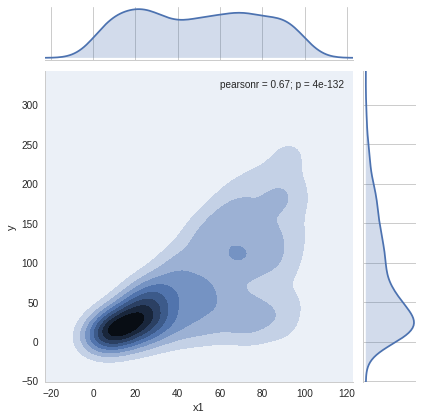

In [69]:
sns.jointplot(x="x1", y="y", data=df, kind="kde", marker = '+')
plt.show()



/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


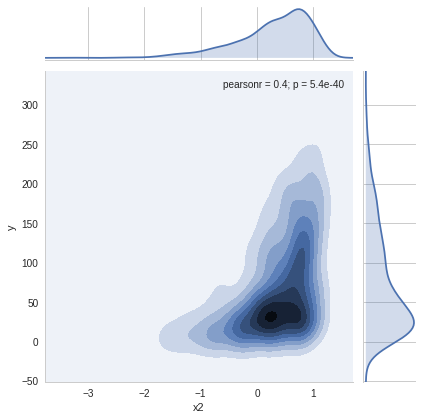

In [70]:
sns.jointplot(x="x2", y="y", data=df, kind="kde")
#sns.plot_joint(plt.scatter, c="w", s=30, linewidth=1, marker="+")
#g.ax_joint.collections[0].set_alpha(0)
plt.show()

/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


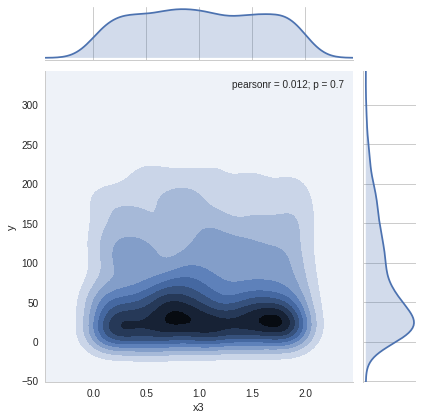

In [71]:
sns.jointplot(x="x3", y="y", data=df, kind="kde")
plt.show()

/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


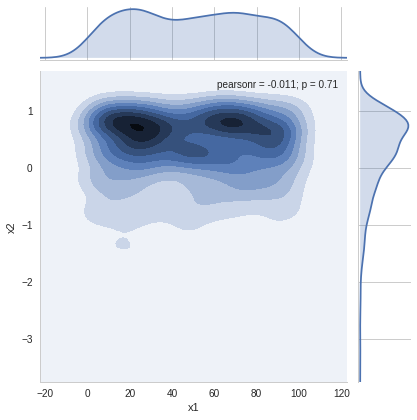

In [72]:
sns.jointplot(x="x1", y="x2", data=df, kind="kde")
plt.show()


/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


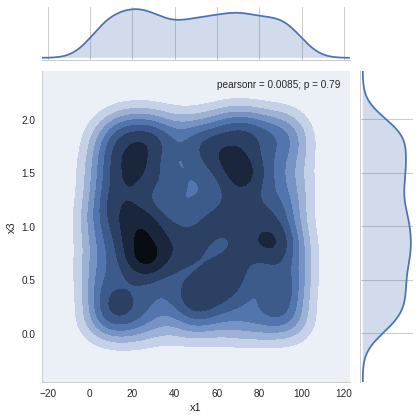

In [73]:
sns.jointplot(x="x1", y="x3", data=df, kind="kde")
plt.show()

/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


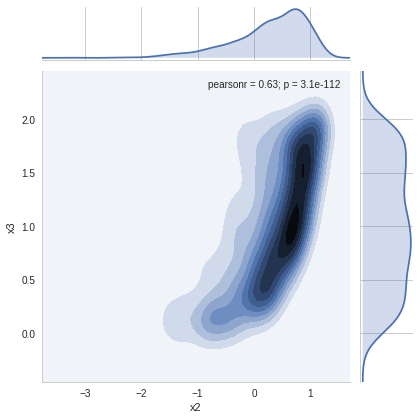

In [74]:
sns.jointplot(x="x2", y="x3", data=df, kind="kde")
plt.show()

In [75]:
from mpl_toolkits.mplot3d import Axes3D

In [76]:
#fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# Axes3D.contour(X, Y, Z, *args, **kwargs)¶

In [77]:
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import scale
from collections import Counter

In [86]:
# Prøver lineær regresjon selv om vi ser at sammenhengen er noe mere kompliser for enkelte av variablene. 
# Vi har kun 3 features og ett relativt lite datasett. Det vil si at det kun er 8 mulige
# kombinasjoner av input features: x1, x2, x3, x1x2,x1x3, x2x3 og x1x2x3. (I prinsippet 9
# hvis vi antar att y er uavhengig av all input variable, men vi ser av datasettet at dette ikke er  tilfelle )
# Vi bare prøver oss frem med all mulig kombinasjoner og ser hva som gir best resultat
# Antar att datsettet er u-ordnet. De 800 første rekkene brukes til generering av modell, og de resterenede
# til validering

lm = LinearRegression(normalize=True)

y_train=df.ix[0:800, (0)]
x1x2x3_train=df.ix[0:800, (1,2,3)]
x1x2_train=df.ix[0:800, (1,2)]
x1x3_train=df.ix[0:800, (1,3)]
x2x3_train=df.ix[0:800, (2,3)]
x1_train=df.ix[0:800, (1)]
x2_train=df.ix[0:800, (2)]
x3_train=df.ix[0:800, (3)]

y_val=df.ix[801:, (0)]
x1x2x3_val=df.ix[801:, (1,2,3)]
x1x2_val=df.ix[801:, (1,2)]
x1x3_val=df.ix[801:, (1,3)]
x2x3_val=df.ix[801:, (2,3)]
x1_val=df.ix[801:, (1)]
x2_val=df.ix[801:, (2)]
x3_val=df.ix[801:, (3)]

In [87]:

lm.fit(x1x2x3_train,y_train)
print ( lm.score(x1x2x3_train, y_train) )
print ("Model score [0,1] using x1, x2 and x3")
print ("LMS Score for training data:\t", lm.score(x1x2x3_train, y_train  ))
print ("LMS Score for validation data:\t", lm.score(x1x2x3_val, y_val ))

0.805415155915
Model score [0,1] using x1, x2 and x3
LMS Score for training data:	 0.805415155915
LMS Score for validation data:	 0.767317865862


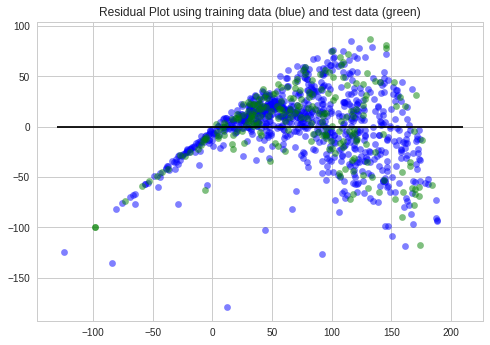

In [80]:
#Vi ser av det forehåned at vi får best resultat når vi bruker alle featurene x1, x2, x3, så vi bruker denne modellen

plt.scatter(lm.predict(x1x2x3_train), lm.predict(x1x2x3_train) - y_train, c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x1x2x3_val), lm.predict(x1x2x3_val) - y_val, c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=-130, xmax=210)
plt.title('Residual Plot using training data (blue) and test data (green)')

plt.show()

# Ser av rest plottet at modellen ikke er spesielt god. For en god modell så burde residuen 
# verdien værr normal fordelt med mean = 0. AV formen på residuene så er det nærliggende
# å forsøke en polynom tilpasning, et 2-grads polynom ser ut til å skulle holde.

Model score [0,1] using x1 and x2 only
LMS Score for training data:	 0.609649967047
LMS Score for validation data:	 0.606207345302


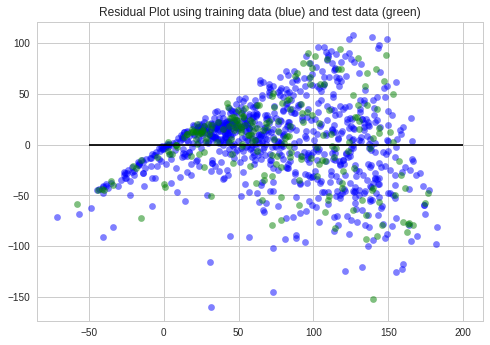

In [81]:
lm.fit(x1x2_train,y_train)
#print ( lm.score(x1x2_train, y_train) )
print ("Model score [0,1] using x1 and x2 only")
print ("LMS Score for training data:\t", lm.score(x1x2_train, y_train  ))
print ("LMS Score for validation data:\t", lm.score(x1x2_val, y_val ))
#Vi gjør det bare litt dårliger når vi dropper x3, grunne er at x3 er sterk korrelert med x2
plt.scatter(lm.predict(x1x2_train), lm.predict(x1x2_train) - y_train, c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x1x2_val), lm.predict(x1x2_val) - y_val, c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=-50, xmax=200)
plt.title('Residual Plot using training data (blue) and test data (green)')

plt.show()

Model score [0,1] using x1 and x3 only
LMS Score for training data:	 0.454026094636
LMS Score for validation data:	 0.410980812189


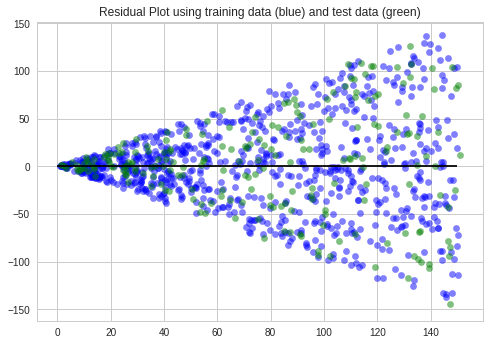

In [82]:
lm.fit(x1x3_train,y_train)
#print ( lm.score(x1x3_train, y_train) )
print ("Model score [0,1] using x1 and x3 only")
print ("LMS Score for training data:\t", lm.score(x1x3_train, y_train  ))
print ("LMS Score for validation data:\t", lm.score(x1x3_val, y_val ))
plt.scatter(lm.predict(x1x3_train), lm.predict(x1x3_train) - y_train, c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x1x3_val), lm.predict(x1x3_val) - y_val, c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=0, xmax=150)
plt.title('Residual Plot using training data (blue) and test data (green)')

plt.show()

Model score [0,1] using x2 and x3 only
LMS Score for training data:	 0.170057646016
LMS Score for validation data:	 0.222508055507


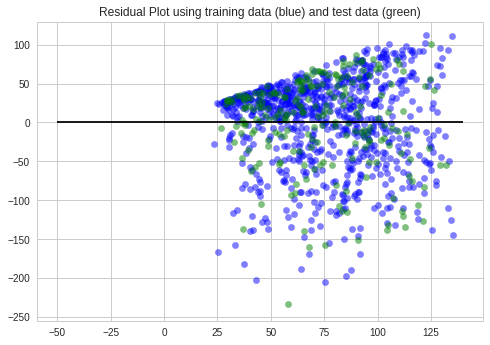

In [48]:
lm.fit(x2x3_train,y_train)
print ("Model score [0,1] using x2 and x3 only")
print ("LMS Score for training data:\t", lm.score(x2x3_train, y_train  ))
print ("LMS Score for validation data:\t", lm.score(x2x3_val, y_val ))

plt.scatter(lm.predict(x2x3_train), lm.predict(x2x3_train) - y_train, c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x2x3_val), lm.predict(x2x3_val) - y_val, c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=-50, xmax=140)
plt.title('Residual Plot using training data (blue) and test data (green)')
plt.show()

Model score [0,1] using x1 only
LMS Score for training data:	 0.454024668386
LMS Score for validation data:	 0.411061772764


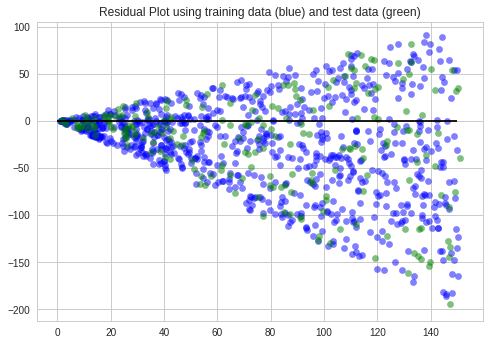

In [49]:
lm.fit(x1_train.values.reshape(-1,1),y_train.values.reshape(-1,1)  )
print ("Model score [0,1] using x1 only")
print ("LMS Score for training data:\t", lm.score(x1_train.values.reshape(-1,1), y_train.values.reshape(-1,1)     ))
print ("LMS Score for validation data:\t", lm.score(x1_val.values.reshape(-1,1), y_val.values.reshape(-1,1)     ))

x1_train_diff = x1_train.values.reshape(-1,1) - y_train.values.reshape(-1,1)
x1_val_diff = x1_val.values.reshape(-1,1) - y_val.values.reshape(-1,1)

# x1_train.values.reshape(-1,1)) - y_train.values.reshape(-1,1)

plt.scatter(lm.predict(x1_train.values.reshape(-1,1)), x1_train_diff , c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x1_val.values.reshape(-1,1) ), x1_val_diff , c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=0, xmax=150)
plt.title('Residual Plot using training data (blue) and test data (green)')
plt.show()

#todo plot med y logaritmisk !!

In [50]:
##lm.fit(x1_val.values.reshape(-1,1),y_val.values.reshape(-1,1)  )


In [51]:
##import matplotlib.pyplot as plt
##import numpy as np
##rng = np.random.RandomState(10)  # deterministic random data
##a = np.hstack((rng.normal(size=1000),rng.normal(loc=5, scale=2, size=1000)))
##plt.hist(x1_val_diff, bins='auto')  # plt.hist passes it's arguments to np.histogram
##plt.title("Histogram with 'auto' bins")
##plt.show()

Model score [0,1] using x2 only
LMS Score for training data:	 0.170057646016
LMS Score for validation data:	 0.222508055507


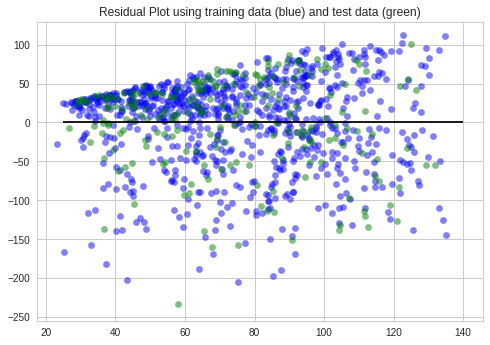

In [52]:
lm.fit(x2_train.values.reshape(-1,1), y_train.values.reshape(-1,1) )
#print ( lm.score(x2_train.values.reshape(-1,1),  y_train.values.reshape(-1,1) ) )
print ("Model score [0,1] using x2 only")
print ("LMS Score for training data:\t", lm.score(x2_train.values.reshape(-1,1), y_train.values.reshape(-1,1)     ))
print ("LMS Score for validation data:\t", lm.score(x2_val.values.reshape(-1,1), y_val.values.reshape(-1,1)     ))


plt.scatter(lm.predict(x2_train.values.reshape(-1,1)), lm.predict(x2_train.values.reshape(-1,1)) - y_train.values.reshape(-1,1), c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x2_val.values.reshape(-1,1) ), lm.predict(x2_val.values.reshape(-1,1) ) - y_val.values.reshape(-1,1), c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=25, xmax=140)
plt.title('Residual Plot using training data (blue) and test data (green)')
plt.show()

Model score [0,1] using x3 only
LMS Score for training data:	 0.000192378969286
LMS Score for validation data:	 -0.00138585960231


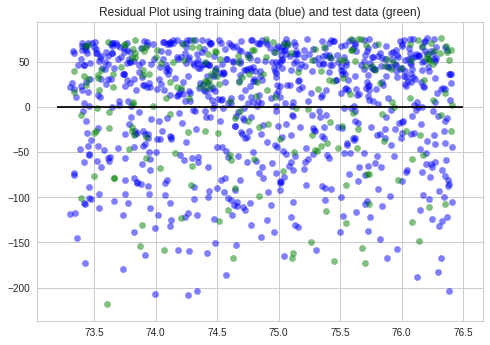

In [96]:
lm.fit(x3_train.values.reshape(-1,1), y_train.values.reshape(-1,1) )
#print ( lm.score(x3_train.values.reshape(-1,1), y_train.values.reshape(-1,1)  ))
print ("Model score [0,1] using x3 only")
print ("LMS Score for training data:\t", lm.score(x3_train.values.reshape(-1,1), y_train.values.reshape(-1,1)     ))
print ("LMS Score for validation data:\t", lm.score(x3_val.values.reshape(-1,1), y_val.values.reshape(-1,1)     ))

plt.scatter(lm.predict(x3_train.values.reshape(-1,1)), lm.predict(x3_train.values.reshape(-1,1)) - y_train.values.reshape(-1,1), c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x3_val.values.reshape(-1,1) ), lm.predict(x3_val.values.reshape(-1,1) ) - y_val.values.reshape(-1,1), c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=73.2, xmax=76.5)
plt.title('Residual Plot using training data (blue) and test data (green)')
plt.show()

Model score [0,1] using x1,x2,x3 and a linearizing plynomial transformation of degree 2
LMS Score for training data:	 0.950022721426
LMS Score for validation data:	 0.945380322089


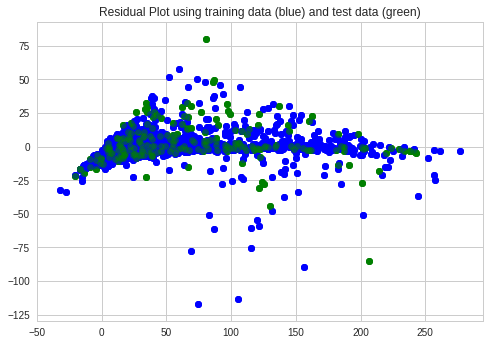

In [111]:
#we try a polynomial fit of degree 2
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

#X = [[0.44, 0.68], [0.99, 0.23]]
#vector = [109.85, 155.72]
#predict= [0.49, 0.18]
#y = df.ix[0:,'y']

poly = PolynomialFeatures(degree=2)
X_train = poly.fit_transform(x1x2x3_train, (1,2,3))
X_val   = poly.fit_transform(x1x2x3_val, (1,2,3))

##y_ = poly.fit_transform(y.values.reshape(-1,1))
clf = linear_model.LinearRegression()


clf.fit(X_train, y_train )

plt.scatter(clf.predict(X_train), clf.predict(X_train) - y_train, c='b', s=40, alpha=0.5)
#plt.hlines(y=0, xmin=-130, xmax=210)
plt.title('Residual Plot using training data (blue) and test data (green)')
print ("Model score [0,1] using x1,x2,x3 and a linearizing plynomial transformation of degree 2")
print ("LMS Score for training data:\t", clf.score(X_train, y_train ))
print ("LMS Score for validation data:\t", clf.score(X_val, y_val ))
plt.show()
#print ( clf.predict(predict_))

In [ ]:
#plt.scatter(diabetes_X_test, diabetes_y_test,  color='black')
#plt.plot(diabetes_X_test, regr.predict(diabetes_X_test), color='blue',
         linewidth=3)
